<a href="https://colab.research.google.com/github/Vinothr007/Skillentrix_Intern/blob/main/Capstone_Project_02_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***STEP 1: IMPORT LIBRARIES***

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


***STEP 2: LOAD DATASETS***

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load datasets

train_df = pd.read_csv('/content/drive/MyDrive/House Prices_train (1).csv')
test_df = pd.read_csv('/content/drive/MyDrive/House Prices_test (1).csv')
# Display first 5 rows

train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


***STEP 3: UNDERSTAND THE DATASET***

In [ ]:
# Shape of datasets

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (1460, 81)
Testing Dataset Shape: (1459, 80)


In [ ]:
# Dataset information

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# Check missing values

missing_values = train_df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


***STEP 4: HANDLE MISSING VALUES***

In [ ]:
# Separate numerical and categorical columns

numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train_df.select_dtypes(include=['object']).columns

In [ ]:
# Numerical columns excluding target variable

numeric_cols = train_df.select_dtypes(
    include=['int64', 'float64']
).columns

numeric_cols = numeric_cols.drop('SalePrice')

# Create imputer

num_imputer = SimpleImputer(strategy='median')

# Fit and transform training data

train_df[numeric_cols] = num_imputer.fit_transform(
    train_df[numeric_cols]
)

# Transform test data

test_df[numeric_cols] = num_imputer.transform(
    test_df[numeric_cols]
)

In [ ]:
# Fill categorical missing values using mode

cat_imputer = SimpleImputer(strategy='most_frequent')

train_df[categorical_cols] = cat_imputer.fit_transform(
    train_df[categorical_cols]
)

test_df[categorical_cols] = cat_imputer.transform(
    test_df[categorical_cols]
)

***STEP 5: EXPLORATORY DATA ANALYSIS (EDA)***

**5.1 Target Variable Distribution**

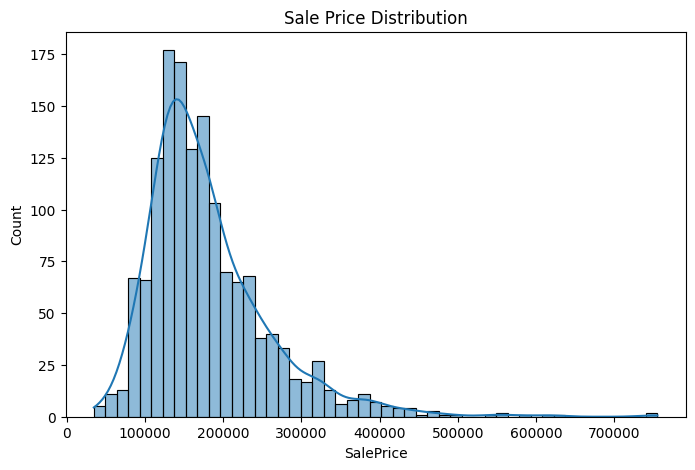

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(train_df['SalePrice'], kde=True)

plt.title("Sale Price Distribution")

plt.show()

**5.2 Correlation Heatmap**

In [ ]:
# Correlation matrix

corr_matrix = train_df.corr(numeric_only=True)

# Top correlated features with SalePrice

top_corr = corr_matrix['SalePrice'].sort_values(ascending=False)

print(top_corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


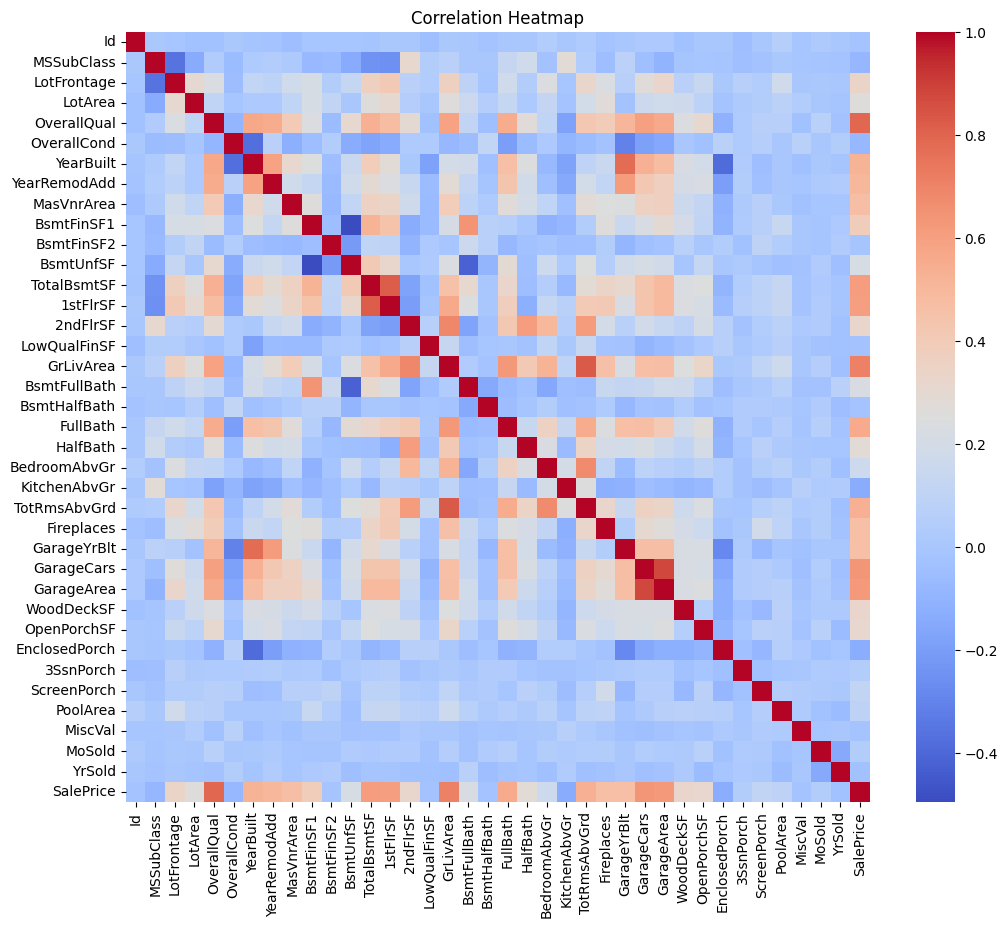

In [ ]:
# Heatmap

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

**5.3 Important Features Visualization**

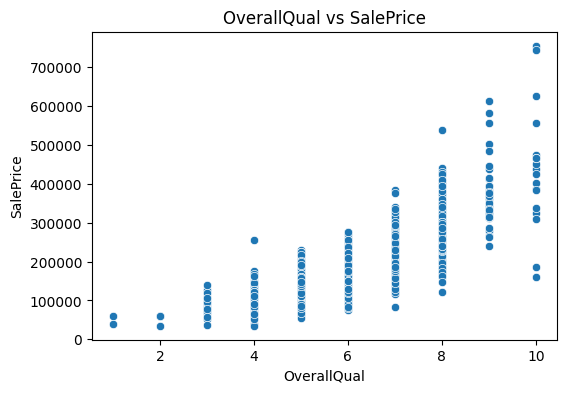

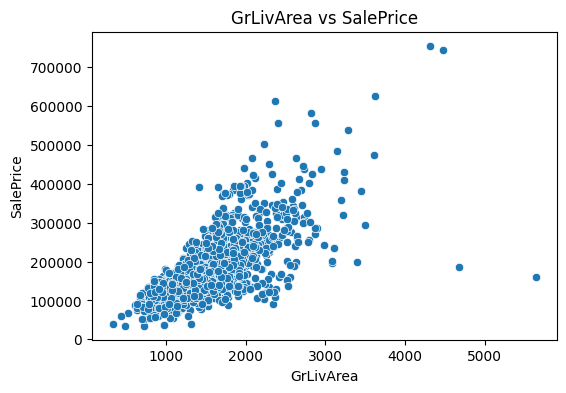

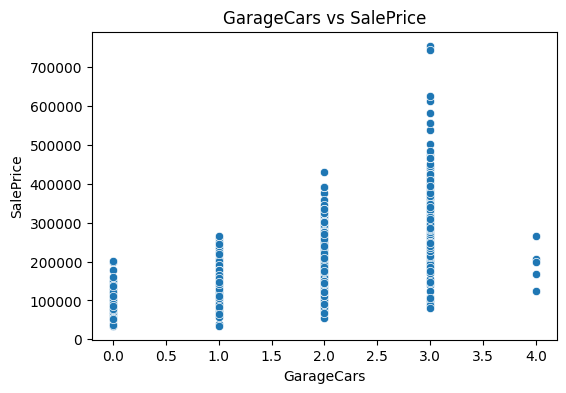

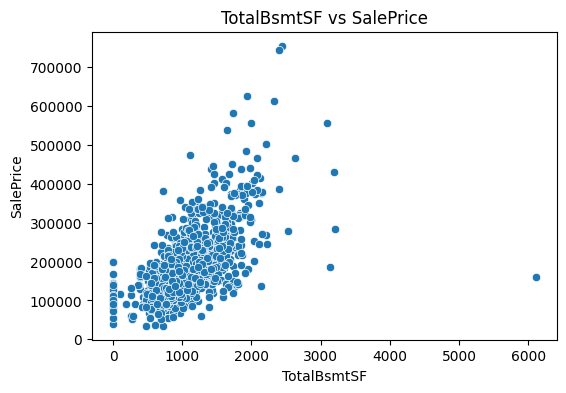

In [ ]:
important_features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF'
]

for feature in important_features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=train_df[feature],
        y=train_df['SalePrice']
    )

    plt.title(f"{feature} vs SalePrice")

    plt.show()

***STEP 6: FEATURE ENGINEERING***

In [ ]:
# Create Total Area Feature

train_df['TotalArea'] = (
    train_df['TotalBsmtSF'] +
    train_df['1stFlrSF'] +
    train_df['2ndFlrSF']
)

test_df['TotalArea'] = (
    test_df['TotalBsmtSF'] +
    test_df['1stFlrSF'] +
    test_df['2ndFlrSF']
)

In [ ]:
# Create House Age Feature

train_df['HouseAge'] = train_df['YrSold'] - train_df['YearBuilt']

test_df['HouseAge'] = test_df['YrSold'] - test_df['YearBuilt']

***STEP 7: ENCODE CATEGORICAL VARIABLES***

In [ ]:
# Combine train and test for consistent encoding

combined_df = pd.concat(
    [train_df.drop('SalePrice', axis=1), test_df],
    axis=0
)

combined_df = pd.get_dummies(combined_df)

combined_df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1.0,60.0,65.0,8450.0,7.0,5.0,2003.0,2003.0,196.0,706.0,...,False,False,False,True,False,False,False,False,True,False
1,2.0,20.0,80.0,9600.0,6.0,8.0,1976.0,1976.0,0.0,978.0,...,False,False,False,True,False,False,False,False,True,False
2,3.0,60.0,68.0,11250.0,7.0,5.0,2001.0,2002.0,162.0,486.0,...,False,False,False,True,False,False,False,False,True,False
3,4.0,70.0,60.0,9550.0,7.0,5.0,1915.0,1970.0,0.0,216.0,...,False,False,False,True,True,False,False,False,False,False
4,5.0,60.0,84.0,14260.0,8.0,5.0,2000.0,2000.0,350.0,655.0,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
# Split back into train and test

X = combined_df.iloc[:train_df.shape[0], :]
X_test_final = combined_df.iloc[train_df.shape[0]:, :]

# Target variable

y = train_df['SalePrice']

***STEP 8: FEATURE SCALING***

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_test_scaled = scaler.transform(X_test_final)

***STEP 9: TRAIN TEST SPLIT***

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Validation Shape:", X_valid.shape)

Training Shape: (1168, 290)
Validation Shape: (292, 290)


***STEP 10: LINEAR REGRESSION MODEL***

In [ ]:
# Create model

lr_model = LinearRegression()

# Train model

lr_model.fit(X_train, y_train)

# Predictions

lr_pred = lr_model.predict(X_valid)

***STEP 11: EVALUATE LINEAR REGRESSION***

In [ ]:
print("LINEAR REGRESSION RESULTS")
print("="*40)

mae = mean_absolute_error(y_valid, lr_pred)

mse = mean_squared_error(y_valid, lr_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_valid, lr_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

LINEAR REGRESSION RESULTS
MAE: 18011.80897090727
MSE: 808206556.7521672
RMSE: 28428.97389552017
R2 Score: 0.8946320488957986


***STEP 12: RIDGE REGRESSION***

In [ ]:
ridge_model = Ridge(alpha=10)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_valid)

In [ ]:
print("RIDGE REGRESSION RESULTS")
print("="*40)

print("R2 Score:", r2_score(y_valid, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, ridge_pred)))

RIDGE REGRESSION RESULTS
R2 Score: 0.8960499974206669
RMSE: 28237.040018766624


***STEP 13: LASSO REGRESSION***

In [ ]:
lasso_model = Lasso(alpha=0.001)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_valid)

In [ ]:
print("LASSO REGRESSION RESULTS")
print("="*40)

print("R2 Score:", r2_score(y_valid, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, lasso_pred)))

LASSO REGRESSION RESULTS
R2 Score: 0.8958726746348089
RMSE: 28261.11378967442


***STEP 14: GRADIENT BOOSTING REGRESSOR***

In [ ]:
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr_model.fit(X_train, y_train)

gbr_pred = gbr_model.predict(X_valid)

In [ ]:
print("GRADIENT BOOSTING RESULTS")
print("="*40)

print("R2 Score:", r2_score(y_valid, gbr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, gbr_pred)))

GRADIENT BOOSTING RESULTS
R2 Score: 0.9054698038081312
RMSE: 26927.262044645977


***STEP 15: MODEL COMPARISON***

In [ ]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Gradient Boosting'
    ],

    'R2 Score': [
        r2_score(y_valid, lr_pred),
        r2_score(y_valid, ridge_pred),
        r2_score(y_valid, lasso_pred),
        r2_score(y_valid, gbr_pred)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_valid, lr_pred)),
        np.sqrt(mean_squared_error(y_valid, ridge_pred)),
        np.sqrt(mean_squared_error(y_valid, lasso_pred)),
        np.sqrt(mean_squared_error(y_valid, gbr_pred))
    ]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.894632,28428.973896
1,Ridge Regression,0.896050,28237.040019
2,Lasso Regression,0.895873,28261.113790
3,Gradient Boosting,0.905470,26927.262045


***STEP 16: HYPERPARAMETER TUNING***

In [ ]:
# Parameters for tuning

params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}

In [ ]:
# Grid Search

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=params,
    cv=3,
    scoring='r2',
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 4],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

In [ ]:
# Best Parameters

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}


In [ ]:
# Best Model

best_model = grid_search.best_estimator_

# Predictions

best_pred = best_model.predict(X_valid)

In [ ]:
# Evaluate Best Model

print("TUNED MODEL RESULTS")
print("="*40)

print("R2 Score:", r2_score(y_valid, best_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_valid, best_pred)))

TUNED MODEL RESULTS
R2 Score: 0.9080344421406175
RMSE: 26559.477190024


***STEP 17: FEATURE IMPORTANCE***

In [ ]:
importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': best_model.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
4,OverallQual,0.374895
37,TotalArea,0.358714
14,2ndFlrSF,0.025862
38,HouseAge,0.023037
16,GrLivArea,0.017987
26,GarageCars,0.017289
3,LotArea,0.016833
9,BsmtFinSF1,0.015027
7,YearRemodAdd,0.012994
250,GarageFinish_Unf,0.010411


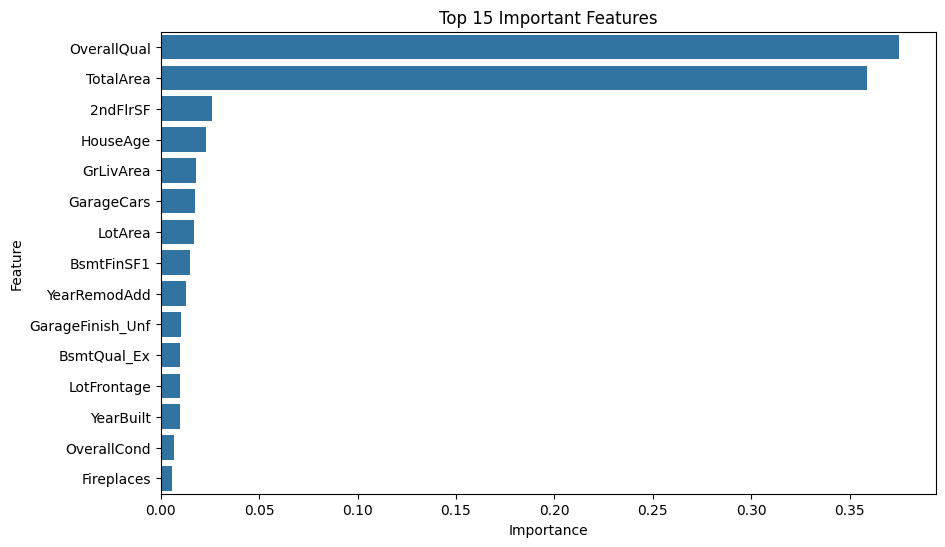

In [ ]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

***STEP 18: ACTUAL VS PREDICTED VALUES***

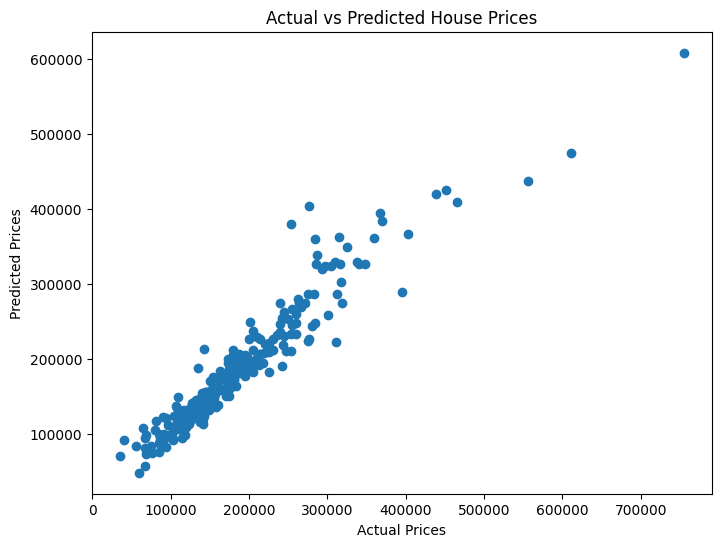

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_valid, best_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

***STEP 19: FINAL TEST PREDICTIONS***

In [ ]:
# Predict on test dataset

final_predictions = best_model.predict(X_test_scaled)

final_predictions

array([132599.32490033, 175592.31983552, 185025.28037864, ...,
       157032.78288752, 125524.19126873, 220096.02967185])

***STEP 20: CREATE SUBMISSION FILE***

In [ ]:
submission = pd.DataFrame({

    'Id': test_df['Id'],
    'SalePrice': final_predictions

})

submission.head()

,Id,SalePrice
0,1461.0,132599.324900
1,1462.0,175592.319836
2,1463.0,185025.280379
3,1464.0,189241.301578
4,1465.0,192921.452827


In [ ]:
# Save CSV file

submission.to_csv('House_Price_Predictions.csv', index=False)

print("Submission File Created Successfully")

Submission File Created Successfully


***STEP 21: BUSINESS INSIGHTS***

BUSINESS INSIGHTS
===================================

1. Overall house quality strongly affects price.

2. Larger living area increases house value.

3. Garage capacity influences property pricing.

4. Basement area contributes significantly.

5. Newer houses generally have higher prices.

6. Feature engineering improved prediction accuracy.

7. Gradient Boosting performed best due to
   its ability to capture complex relationships.

***STEP 22: FINAL CONCLUSION***

FINAL CONCLUSION
===================================

This project successfully predicts house prices
using Machine Learning Regression techniques.

Models Used:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Gradient Boosting Regressor

Techniques Applied:
- Missing Value Handling
- Feature Engineering
- Feature Scaling
- Hyperparameter Tuning

The Gradient Boosting model achieved the
best performance and produced accurate predictions.

This project is useful for:
- Real Estate Price Estimation
- Property Investment Analysis
- Market Trend Prediction
- Business Decision Making

